<a href="https://colab.research.google.com/github/shreyoshi2304/RNN-Auditory/blob/main/RNN_vs_RateModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

# =========================
# SPECTRO-TEMPORAL DATA
# =========================
def generate_spectrogram_data(n_samples=200, seq_len=80, n_freq=20):
    X = []
    Y = []

    for _ in range(n_samples):
        freq = np.random.uniform(2, 10)
        t = np.linspace(0, 1, seq_len)

        spec = np.zeros((seq_len, n_freq))

        for f_bin in range(n_freq):
            center = f_bin / n_freq * 10
            signal = np.sin(2 * np.pi * freq * t)

            weight = np.exp(-(center - freq)**2 / 2)
            spec[:, f_bin] = weight * signal

        spec += np.random.normal(0, 0.1, spec.shape)

        X.append(spec)
        Y.append(freq)

    return np.array(X), np.array(Y)


X, Y = generate_spectrogram_data()

X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

In [ ]:
class AuditoryRNN(nn.Module):
    def __init__(self, input_size=20, hidden_size=40):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]), out


rnn_model = AuditoryRNN()

In [ ]:
class RateModel(nn.Module):
    def __init__(self, input_size=20):
        super().__init__()
        self.fc = nn.Linear(input_size, 1)

    def forward(self, x):
        # average over time (no temporal memory)
        x_mean = x.mean(dim=1)
        return self.fc(x_mean)


rate_model = RateModel()

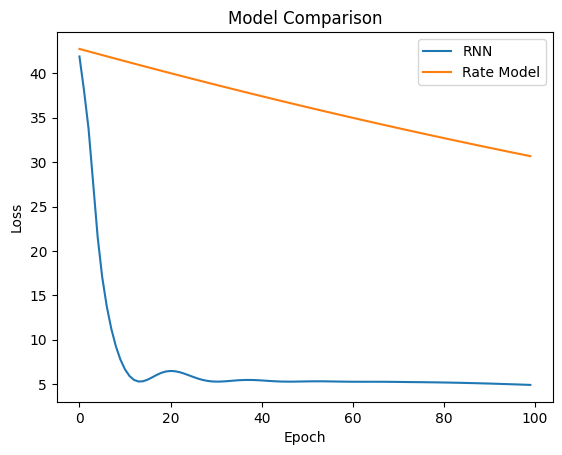

In [ ]:
def train_model(model, X, Y, epochs=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(X)[0] if isinstance(model, AuditoryRNN) else model(X)
        loss = criterion(pred.squeeze(), Y)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return losses


loss_rnn = train_model(rnn_model, X, Y)
loss_rate = train_model(rate_model, X, Y)

# Plot comparison
plt.figure()
plt.plot(loss_rnn, label="RNN")
plt.plot(loss_rate, label="Rate Model")
plt.legend()
plt.title("Model Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()